In [1]:
def baric_corr(carpeta):
    from astropy.io import fits
    from astropy.time import Time
    from astropy.coordinates import SkyCoord, EarthLocation
    import astropy.units as u
    from astropy.constants import c
    import numpy as np
    import glob 
    import os
    
    patron = os.path.join(carpeta, '*AIR_modificado.fits')#Gran*-star*_sum_m*_fsr1.05_AIR_modificado.fits
    archivos= glob.glob(patron)

    if not archivos:
        print(f"no se encontraron archivos en: {carpeta}")
        return
    print(f'se encontraron {len(archivos)} archivos')
    v_s= []
    for archivo in archivos:
        print(f'procesando {archivo}')
        # leer el fits
        hdul = fits.open(archivo)
        hdr = hdul[0].header
        flux = hdul[0].data

        ra = hdr['RA']
        dec = hdr['DEC']
        date = hdr['DATE-OBS']
        obj = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
        location = EarthLocation.of_site("La Silla Observatory")
        location = location.to_geodetic()
        t = Time(date, format = 'mjd', location=location)
        barycorr = obj.radial_velocity_correction(obstime=t)
        v_bc = barycorr.to(u.km/u.s).value
        v_s.append(v_bc)
    return(np.median(v_s))   
    

In [2]:
import numpy as np


In [3]:
st1 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star1/')
st3 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star3/')
st4 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star4/')
st7 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star7/')
st8 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star8/')
st9 = baric_corr('/home/nacho/molecfit_test/mis_outputs_star9/')

se encontraron 13 archivos
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m43_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m44_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m45_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m46_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m47_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m48_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m51_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m52_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/mis_outputs_star1/Gran01-star3_sum_m53_fsr1.05_AIR_modificado.fits
procesando /home/nacho/molecfit_test/

In [18]:
print([st1, st3, st4, st7, st8, st9])

[np.float64(-28.798994131016897), np.float64(-28.778747427250078), np.float64(-23.216648693749924), np.float64(-23.119686136143773), np.float64(-28.75532046297133), np.float64(-23.159385729881496)]


# para pasar de vacio a aire

In [4]:
def vac_to_air(wavelength_vac):
    import numpy as np
    wl_vac = np.atleast_1d(wavelength_vac)
    
    sigma2 = (1e4 / wl_vac)**2
    # indice de refracción del aire (n-1) * 10^8
    # n_minus_1 = 6432.8 + 2949810.0 / (146.0 - sigma2) + 25540.0 / (41.0 - sigma2) # edlen 1953
    # n_minus_1 = 8343.05 + 2406294.0 / (130.0 - sigma2) + 15999 / (38.9 - sigma2) # birch 1993
    n_minus_1 = 8342.54 + 2406147 / (130 - sigma2) + 15998 / (38.9 - sigma2) # vald
    n_minus_1 *= 1e-8
    
    n = 1.0 + n_minus_1
    
    # Conversión de vacío a aire
    wl_air = wl_vac / n
    
    print(f"el indice de refraccion es:{n} ")
    return wl_air
def vacuum_a_air(ruta_carpeta):
    from astropy.io import fits
    from shutil import copyfile
    import os 
    import glob
    
    patron = os.path.join(ruta_carpeta, '*par_tac.fits')
    archivos = glob.glob(patron)
    
    if not archivos:
        print(f"No se encontraron archivos que terminen en 'par_tac.fits' en la carpeta: {ruta_carpeta}")
        return
    
    print(f"Se encontraron {len(archivos)} archivos para procesar:")
    for archivo in archivos:
        print(f"  - {os.path.basename(archivo)}")
    
    for archivo in archivos:
        print(f"\nProcesando: {archivo}")
        
        # Copia de seguridad
        backup = archivo.replace('.fits', '_backup_vacuum.fits')
        if not os.path.exists(backup):
            copyfile(archivo, backup)
            print(f"  Copia de seguridad creada: {backup}")
        else:
            print(f"  Copia de seguridad ya existe: {backup}")
        
        
        with fits.open(backup, mode='update') as hdul:
            datos = hdul[1].data
            long_onda = datos['LAMBDA']
            
            # Convertir y sobreescribir
            datos['LAMBDA'] = vac_to_air(long_onda)
            
            # Con mode='update', flush() guarda los cambios
            hdul.flush()
        
        print(f"  ¡Listo! {backup} ahora tiene longitudes de onda en AIRE")
    
    print(f"\nProcesamiento completado. Total de archivos procesados: {len(archivos)}")

In [5]:
archivos = "/home/nacho/molecfit_test/norm_stars1/"
vacuum_a_air(archivos)
archivos3 = "/home/nacho/molecfit_test/norm_stars3/"
vacuum_a_air(archivos3)
archivos4 = "/home/nacho/molecfit_test/norm_stars4/"
vacuum_a_air(archivos4)
archivos7 = "/home/nacho/molecfit_test/norm_stars7/"
vacuum_a_air(archivos7)
archivos8 = "/home/nacho/molecfit_test/norm_stars8/"
vacuum_a_air(archivos8)
archivos9 = "/home/nacho/molecfit_test/norm_stars9/"
vacuum_a_air(archivos9)

Se encontraron 14 archivos para procesar:
  - Gran01-star3_sum_m43_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m44_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m45_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m46_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m47_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m48_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m51_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m52_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m53_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m54_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m55_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m56_AIR_normalizado.par_tac.fits
  - Gran01-star3_sum_m57_AIR_normalizado.par_tac.fits
  - _stars1interpolado.par_tac.fits

Procesando: /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m43_AIR_normalizado.par_tac.fits
  Copia de seguridad ya existe: /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m43_AIR_normalizado.par_tac_back

# aplicar CCF

In [7]:
def cross_corr_apli(carpeta):
    """esta funcion se encarga de hacer el CCF y aplicar también la correccion por velocidad baricentrica
    input: 
    carpeta: corresponde a la carpeta en donde se encuentran nuestros archivos fits, ya sean los archivos
    fits de calctrans o los archivos fits que necesita la funcon baric_corr
    
    outputs: entrega un .dat con el CCF ademas de graficos png para observar el fit"""
    import glob
    import os
    import re
    import subprocess
    from astropy.io import fits
    import matplotlib.pyplot as plt
    # carpeta 
    grillas = "/home/nacho/molecfit_test/winered_R28k_airGrid/" # grilla en aire 
    #grillas = "/home/nacho/molecfit_test/winered_R28K_vacGrid/" # grilla en vacio 

    # buscar los ordenes /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m43_AIR_normalizado.par_tac.fits
    archivos = sorted(glob.glob(os.path.join(carpeta, "**", "*AIR_normalizado.par_tac.fits"), recursive=True)) #par_tac_backup_vacuum / par_tac.fits /AIR.fits
    
    if not archivos:
        print(" No se encontraron archivos _par_tac.fits.")
        return
    ordenes_validos = []
    for ruta in archivos:
        match = re.search(r'_m(\d+)_', ruta)
        if match:
            orden = int(match.group(1))
            ordenes_validos.append((orden, ruta))
    # ordenar por el numero de orden 
    ordenes_validos.sort(key=lambda x: x[0])

    for orden, ruta in ordenes_validos:
        print(f"\n Procesando orden {orden}...")
        cmd = [
            "python3", "rvcorr_fitsTableSpec.py",
            ruta,
            grillas,
            "--vmin", "50",
            "--vmax", "120",
            "-n"
        ]
        # graficar espectros 
        with fits.open(ruta) as hdul:
            labda = hdul[1].data['LAMBDA']
            flux = hdul[1].data['CFLUX']
            plt.plot(labda, flux)
        try:
            subprocess.run(cmd, check=True)
            print(f"Orden {orden} procesado con éxito.")
        except subprocess.CalledProcessError:
            print(f" Error procesando orden {orden}.")

# correr solo un espectro en caso de

In [8]:
def solo_1_espectro(espectro):
    import glob
    import os
    import re
    import subprocess
    grillas = grillas = "/home/nacho/molecfit_test/winered_R28K_vacGrid/"
    match = re.search(r'_m(\d+)_', espectro)
    if match:
        orden= int(match.group(1))
        print(f'leyendo orden {orden }')
    cmd = [
            "python3", "rvcorr_fitsTableSpec.py",
            espectro,
            grillas,
            "--vmin", "100",
            "--vmax", "110",
            "-n"
        ]
    try:
        subprocess.run(cmd, check=True)
        print(f"Orden {orden} procesado con éxito.")
    except subprocess.CalledProcessError:
        print(f" Error procesando orden {orden}.")


 Procesando orden 43...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  113.50
[Info] Best template chisquare:  0.0017539700912272335
[Info] ccf Vobs:  113.600
[Info] Final Vobs:  113.591
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  113.50
[Info] Best template chisquare:  0.0009196178738954831
[Info] ccf Vobs:  113.325
[Info] Final Vobs:  113.320
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars1/Gran01-star3_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results w

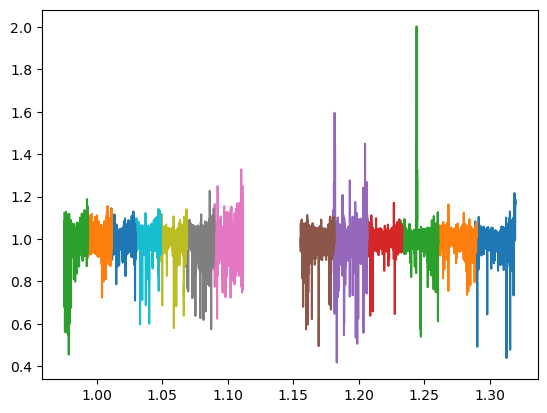

In [24]:
#estrella 1 
carpeta = "/home/nacho/molecfit_test/norm_stars1/"
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star1/"
cross_corr_apli(carpeta)


 Procesando orden 43...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  116.00
[Info] Best template chisquare:  0.0023170416535229633
[Info] ccf Vobs:  116.025
[Info] Final Vobs:  115.968
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars3/Gran01-star3_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars3/Gran01-star3_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  114.50
[Info] Best template chisquare:  0.0007400199509720558
[Info] ccf Vobs:  114.650
[Info] Final Vobs:  115.722
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars3/Gran01-star3_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results w

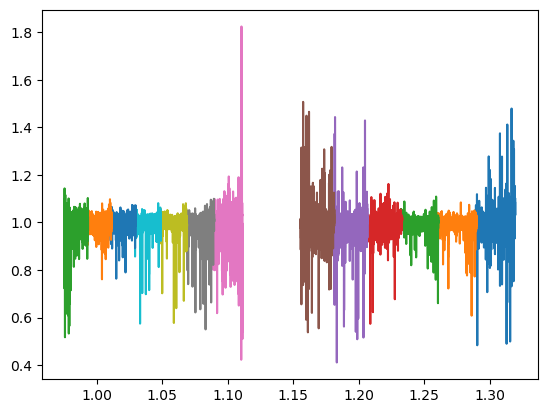

In [25]:
#estrella 3 
carpeta = "/home/nacho/molecfit_test/norm_stars3/"
#carpeta = "/home/nacho/molecfit_test/ordenes_star3/"
#vacuum_a_air(carpeta)
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star3/"
cross_corr_apli(carpeta)


 Procesando orden 43...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  120.00)
[Info] Preliminary Vobs:  104.50
[Info] Best template chisquare:  0.0014487273876919438
[Info] ccf Vobs:  104.000
[Info] Final Vobs:  103.999
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars4/Gran1-star4_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars4/Gran1-star4_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  120.00)
[Info] Preliminary Vobs:  104.50
[Info] Best template chisquare:  0.0007647699544678802
[Info] ccf Vobs:  104.575
[Info] Final Vobs:  104.571
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars4/Gran1-star4_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results writ

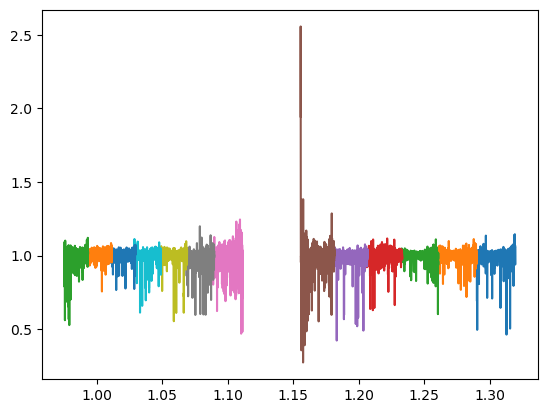

In [9]:
#estrella 4
#carpeta = "/home/nacho/molecfit_test/ordenes_star4/"
carpeta = "/home/nacho/molecfit_test/norm_stars4/"
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star4/"
#vacuum_a_air(carpeta)
cross_corr_apli(carpeta)


 Procesando orden 43...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  105.50
[Info] Best template chisquare:  0.0006370586803964638
[Info] ccf Vobs:  105.175
[Info] Final Vobs:  105.500
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars7/Gran1-star7_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars7/Gran1-star7_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  105.50
[Info] Best template chisquare:  0.00038123060888649296
[Info] ccf Vobs:  105.875
[Info] Final Vobs:  105.875
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars7/Gran1-star7_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results wri

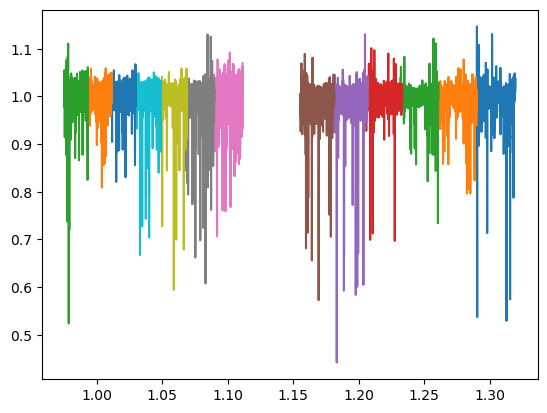

In [27]:
#estrella 7
#carpeta = "/home/nacho/molecfit_test/ordenes_star7/"
carpeta = "/home/nacho/molecfit_test/norm_stars7/"
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star7/"
#vacuum_a_air(carpeta)
cross_corr_apli(carpeta)

In [28]:
#espectro = "/home/nacho/molecfit_test/mis_outputsVAC_star7/Gran1-star7_sum_m53_fsr1.05_VAC_modificado.par_tac.fits"
#solo_1_espectro(espectro)


 Procesando orden 43...


Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  117.00
[Info] Best template chisquare:  0.0009669026435454037
[Info] ccf Vobs:  116.425
[Info] Final Vobs:  116.430
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars8/Gran01-star8_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars8/Gran01-star8_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  116.00
[Info] Best template chisquare:  0.0005925593528618534
[Info] ccf Vobs:  115.825
[Info] Final Vobs:  115.818
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars8/Gran01-star8_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/mo

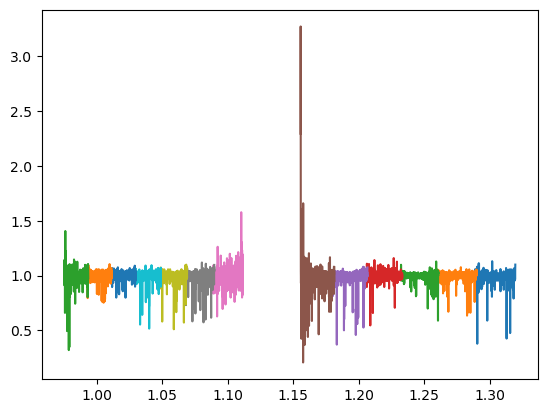

In [29]:
#estrella 8
#carpeta = "/home/nacho/molecfit_test/ordenes_star8/"
carpeta = "/home/nacho/molecfit_test/norm_stars8/"
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star8/"
#vacuum_a_air(carpeta)
cross_corr_apli(carpeta)


 Procesando orden 43...


Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  103.00
[Info] Best template chisquare:  0.0006763212770823638
[Info] ccf Vobs:  102.850
[Info] Final Vobs:  102.847
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars9/Gran1-star9_sum_m43_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molecfit_test/norm_stars9/Gran1-star9_sum_m43_AIR_normalizado.par_tac_RV.dat

Orden 43 procesado con éxito.

 Procesando orden 44...
Figure(640x480)
[Info] Number of templates:  215
[Info] Inputs allow to compute velocity shifts in(   50.00,  150.00)
[Info] Preliminary Vobs:  103.50
[Info] Best template chisquare:  0.0003896234367233137
[Info] ccf Vobs:  103.325
[Info] Final Vobs:  103.312
[Info] Corrected spectrum written in:  /home/nacho/molecfit_test/norm_stars9/Gran1-star9_sum_m44_AIR_normalizado.par_tac_vcorr.fits
[Info] Results written in  /home/nacho/molec

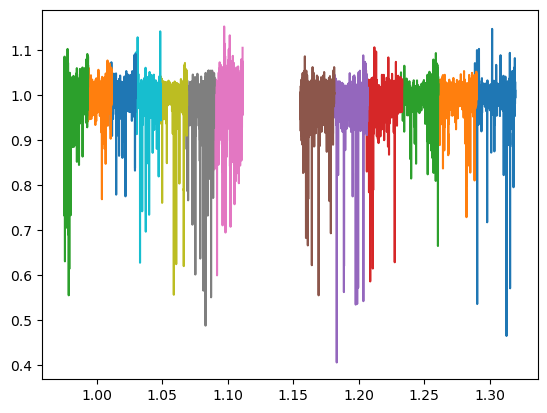

In [30]:
#estrella 9
#carpeta = "/home/nacho/molecfit_test/ordenes_star9/"
carpeta = "/home/nacho/molecfit_test/norm_stars9/"
#carpeta = "/home/nacho/molecfit_test/mis_outputsVAC_star9/"
#vacuum_a_air(carpeta)
cross_corr_apli(carpeta)

# ahora vamos a buscar las velocidades radiales en los archivos 


In [10]:
import os

# Carpetas donde se encuentran los outputs de rvcorr_fitsTableSpec
carpetas = [
    "/home/nacho/molecfit_test/norm_stars1/",
    "/home/nacho/molecfit_test/norm_stars3/",
    "/home/nacho/molecfit_test/norm_stars4/",
    "/home/nacho/molecfit_test/norm_stars7/",
    "/home/nacho/molecfit_test/norm_stars8/",
    "/home/nacho/molecfit_test/norm_stars9/"]
# carpetas = [
#     "/home/nacho/molecfit_test/mis_outputsVAC_star1//",
#     "/home/nacho/molecfit_test/mis_outputsVAC_star3/",
#     "/home/nacho/molecfit_test/mis_outputsVAC_star4/",
#     "/home/nacho/molecfit_test/mis_outputsVAC_star7/",
#     "/home/nacho/molecfit_test/mis_outputsVAC_star8/",
#     "/home/nacho/molecfit_test/mis_outputsVAC_star9/"
#]
# carpetas = [
#     "/home/nacho/molecfit_test/ordenes_star1/",
#     "/home/nacho/molecfit_test/ordenes_star3/",
#     "/home/nacho/molecfit_test/ordenes_star4/",
#     "/home/nacho/molecfit_test/ordenes_star7/",
#     "/home/nacho/molecfit_test/ordenes_star8/",
#     "/home/nacho/molecfit_test/ordenes_star9/"
# ]
for carpeta in carpetas:
    print("\n Revisando:", carpeta)
    for root, dirs, files in os.walk(carpeta):
        for f in files:
            if f.lower().endswith(".dat"):
                print("   ", f)
def extraer_rvs(carpeta):
    import os
    import glob
    import numpy as np

    # Buscar archivos .dat dentro de la carpeta
    archivos = sorted(glob.glob(os.path.join(carpeta, "**", "*AIR_normalizado.par_tac_RV.dat"), recursive=True))# par_tac_RV.dat AIR_RV.dat

    
    if not archivos:
        print(f" No se encontraron archivos .dat en {carpeta}")
        return []

    rvs = []
    for ruta in archivos:
        with open(ruta, "r") as f:
            for linea in f:
                linea = linea.strip()
                if not linea or linea.startswith("#"):
                    continue
                partes = linea.split()
                if len(partes) > 1:
                    try:
                        rv = float(partes[1])  # segundo dato numérico
                        rvs.append(rv)
                    except ValueError:
                        continue  # ignora líneas no numéricas
    print(f"{os.path.basename(os.path.normpath(carpeta))}: {len(rvs)} valores leidos ")
    print(f"{os.path.basename(os.path.normpath(carpeta))}: la deviacion estandar es: {np.std(rvs)}")
    return rvs

# Procesar todas las carpetas
rvs = []

for c in carpetas:
    rvs.append(extraer_rvs(c))




 Revisando: /home/nacho/molecfit_test/norm_stars1/
    Gran01-star3_sum_m43_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m44_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m45_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m46_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m47_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m48_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m51_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m52_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m53_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m54_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m55_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m56_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m57_AIR_normalizado.par_tac_RV.dat

 Revisando: /home/nacho/molecfit_test/norm_stars3/
    Gran01-star3_sum_m43_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m44_AIR_normalizado.par_tac_RV.dat
    Gran01-star3_sum_m45_AIR_normalizado.par_tac_RV.dat


In [11]:
import numpy as np

rbcs = [st1, st3, st4, st7, st8, st9]
rvs_final = []
print(f"las velocidades baricentricas son: {rbcs}")
xd = 0
while xd < 6:
    print(f"velocidad radial estrella {xd} = {np.median(rvs[xd])+rbcs[xd]} km/s")
    rvs_final.append(np.median(rvs[xd])+rbcs[xd])
    xd += 1


las velocidades baricentricas son: [np.float64(-28.798994131016897), np.float64(-28.778747427250078), np.float64(-23.216648693749924), np.float64(-23.119686136143773), np.float64(-28.75532046297133), np.float64(-23.159385729881496)]
velocidad radial estrella 0 = 84.1360058689831 km/s
velocidad radial estrella 1 = 85.90525257274992 km/s
velocidad radial estrella 2 = 80.73235130625008 km/s
velocidad radial estrella 3 = 81.49131386385623 km/s
velocidad radial estrella 4 = 86.96967953702867 km/s
velocidad radial estrella 5 = 78.9056142701185 km/s


In [33]:
# rvs = [113,116,104,105,116,103]
# rvs_ff = []
# a = 0
# while a<6:
#     rvs_ff.append(rvs[a]+rvs_final[a])
#     a +=1
# rvs_ff
